In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [2]:
# To ensure reproducibility
np.random.seed(42)

# Read data from Excel file
file_path = 'clusters-4-v0.csv'
input_df = pd.read_csv(file_path)

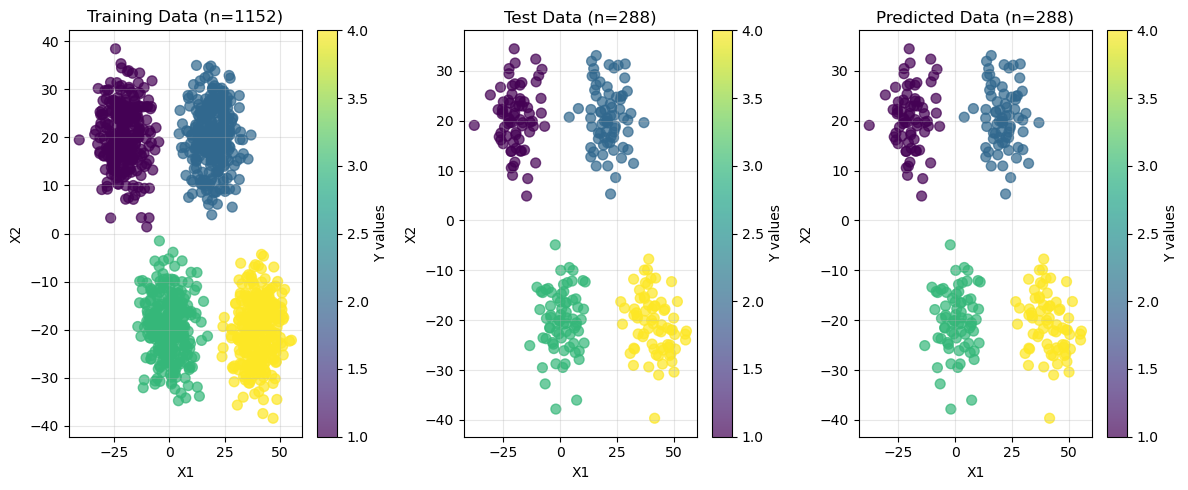

In [37]:
# Scatter Plot with 'x1' and 'y' columns ---
# Select the specified columns
x = input_df.drop(columns=['y'])
y = input_df['y']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
log_reg = LogisticRegression(random_state=42, multi_class='ovr', max_iter=1000)
log_reg.fit(x_train, y_train)
y_pred = log_reg.predict(x_test)

# Create the scatter plot
def print_plots(x_train, x_test, y_train, y_test, y_pred):
    fig, axes = plt.subplots(1, 3, figsize=(12, 5))

    # Training data scatter plot
    scatter1 = axes[0].scatter(x_train['x1'], x_train['x2'], c=y_train, cmap='viridis', alpha=0.7, s=50)
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    axes[0].set_title(f'Training Data (n={len(x_train)})')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Y values')

    # Testing data scatter plot
    scatter2 = axes[1].scatter(x_test['x1'], x_test['x2'], c=y_test, cmap='viridis', alpha=0.7, s=50)
    axes[1].set_xlabel('X1')
    axes[1].set_ylabel('X2')
    axes[1].set_title(f'Test Data (n={len(x_test)})')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[1], label='Y values')

    scatter3 = axes[2].scatter(x_test['x1'], x_test['x2'], c=y_pred, cmap='viridis', alpha=0.7, s=50)
    axes[2].set_xlabel('X1')
    axes[2].set_ylabel('X2')
    axes[2].set_title(f'Predicted Data (n={len(x_test)})')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[2], label='Y values')

    plt.tight_layout()
    plt.show()

print_plots(x_train, x_test, y_train, y_test, y_pred)

In [36]:
poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)

# 3. Standardize (important after poly expansion)
scaler = StandardScaler()
x_poly_scaled = scaler.fit_transform(x_poly)
x_train, x_test, y_train, y_test = train_test_split(x_poly_scaled, y, test_size=0.2, random_state=42, stratify=y)

log_reg = LogisticRegression(random_state=42, multi_class='ovr', max_iter=1000)
log_reg.fit(x_train, y_train)

# Make predictions
y_test_pred = log_reg.predict(x_test)
# print_plots(x_train, x_test, y_train, y_test, y_test_pred)


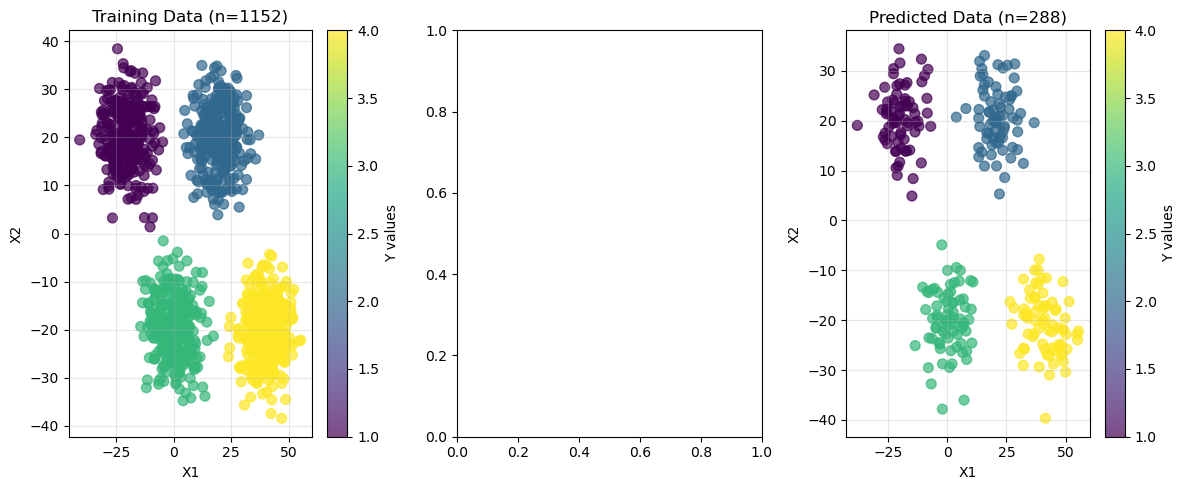

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print_plots(x_train, x_test, y_train, y_test, y_pred)

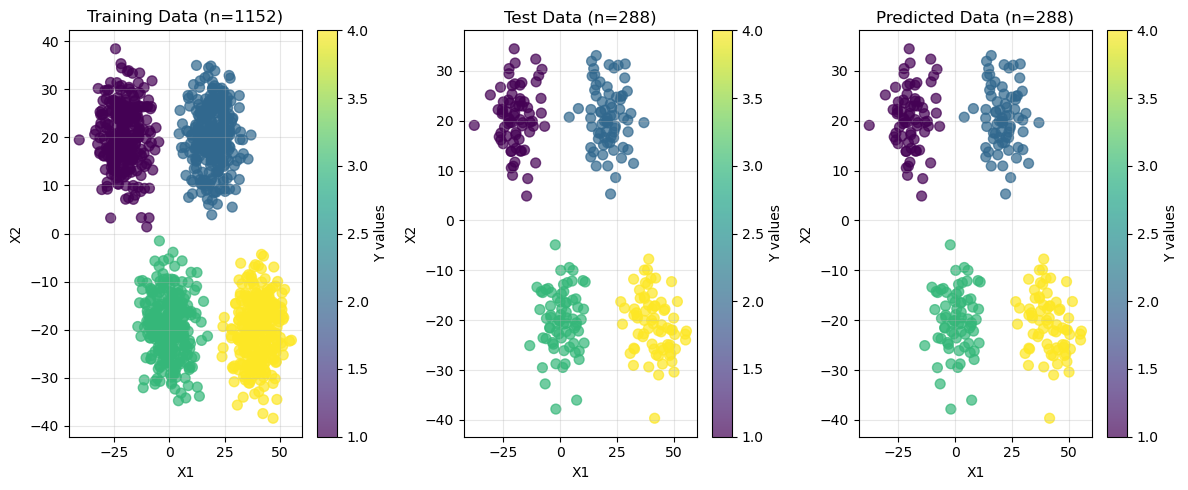

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
model = SVC(kernel='rbf', probability=True, random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print_plots(x_train, x_test, y_train, y_test, y_pred)

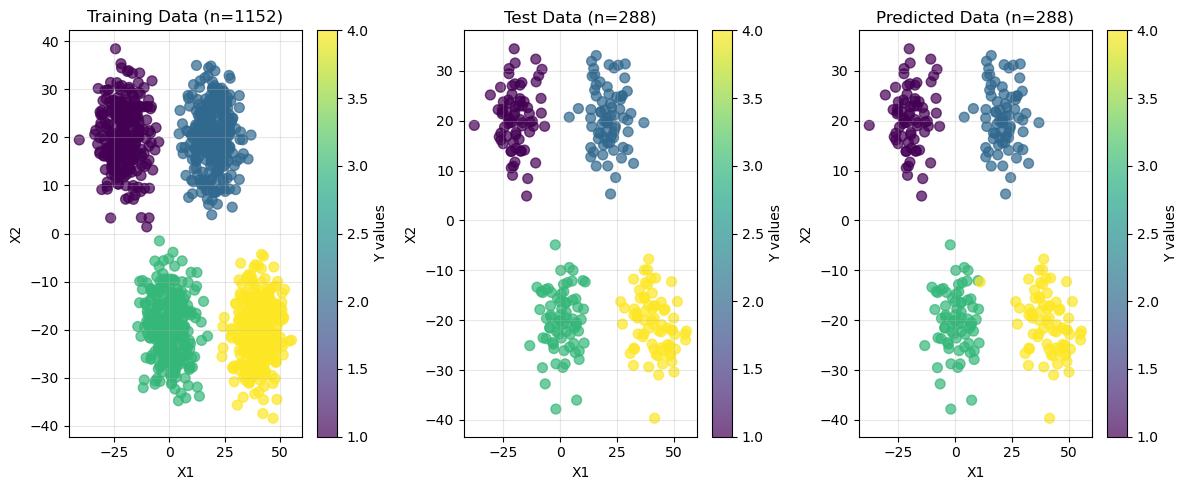

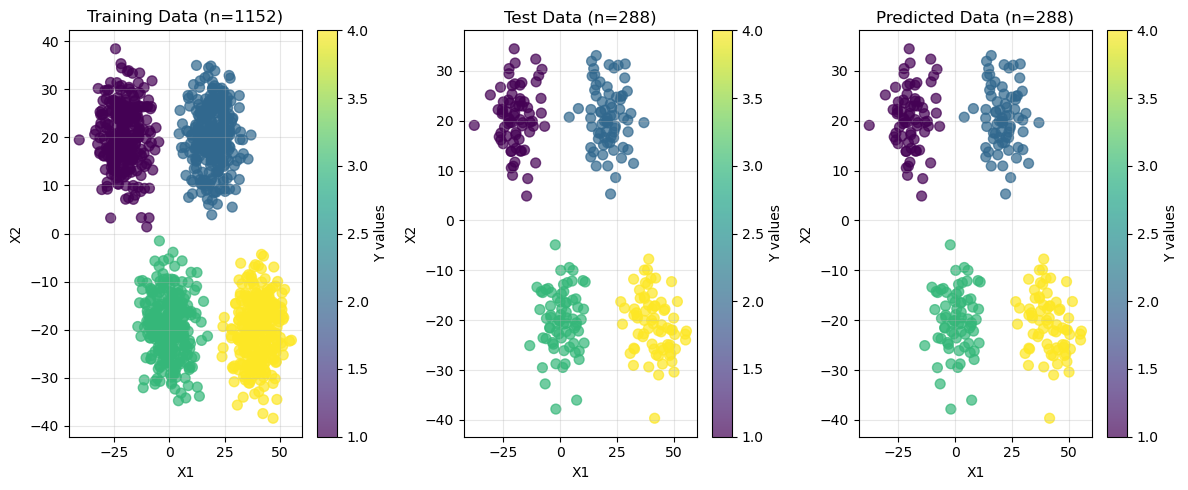

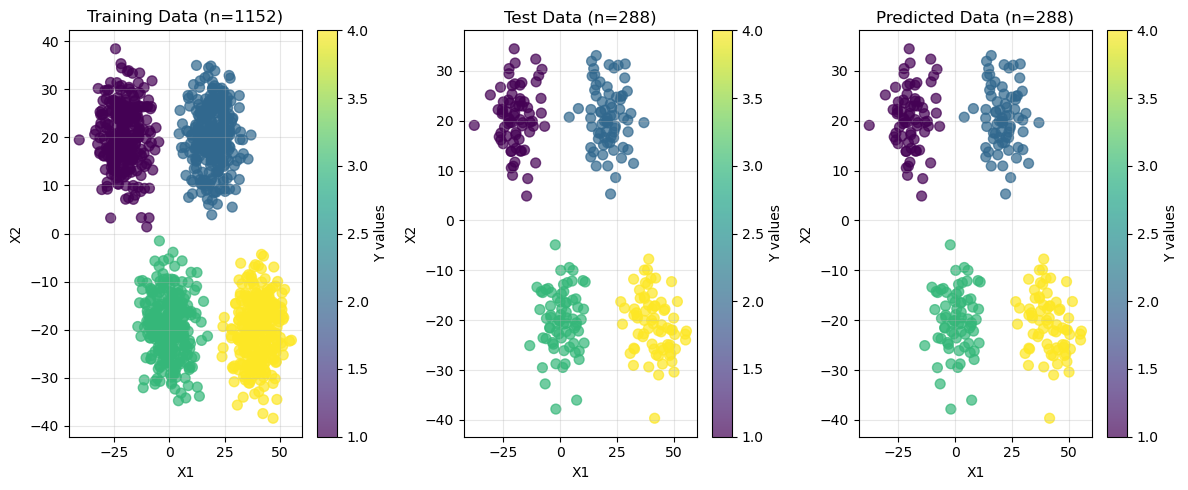

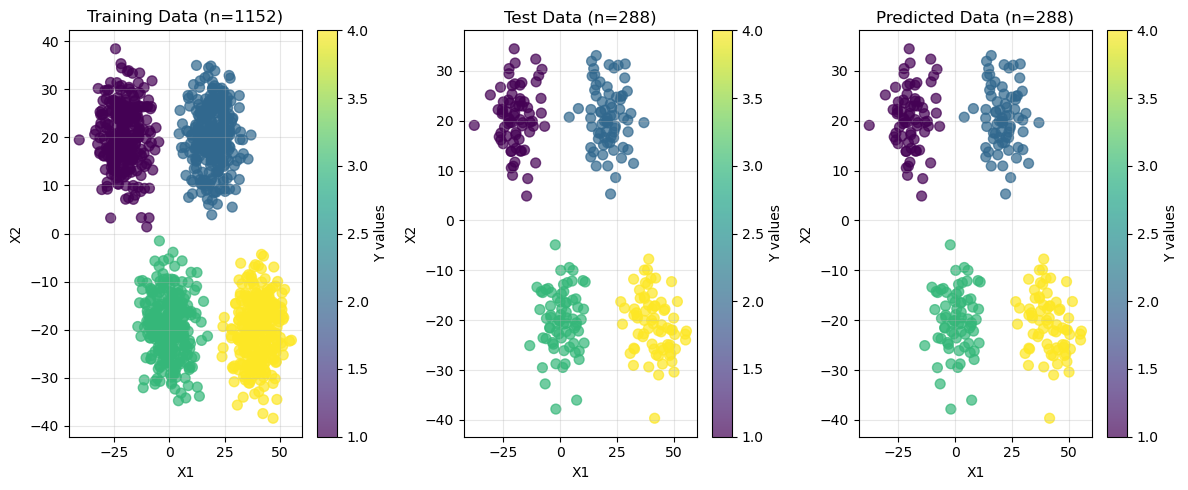

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

hidden_layer_size = [(5), (5, 5), (5, 5, 5), (10)]
for hidden_layer_size in hidden_layer_size:
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_size,  # two hidden layers of 10 neurons each
        activation='relu',  # ReLU = Rectified Linear Unit
        solver='adam',  # popular optimizer
        max_iter=2000,
        random_state=42
    )

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print_plots(x_train, x_test, y_train, y_test, y_pred)